# 🛰️ SPADES V35 — Real Data Pipeline Visualisation
**Loads a real `.h5` training file and shows exactly what the model sees at every stage.**

Run cells top-to-bottom. Change `H5_FILE` and `FRAME_IDX` to inspect different samples.

In [2]:
pip install h5py

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 74.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── CONFIG — change these ────────────────────────────────────────────────────
H5_FILE   = 'data_old/RT001.h5'   # path to any training h5 file
FRAME_IDX = 150                # which labelled frame to inspect (0 = first)
WINDOW_MS = 400                # event window in milliseconds
SEED      = 42
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib import cm
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import h5py, random, io, math
from PIL import Image

np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)

RES    = 320
T_BINS = 9
N_CH   = T_BINS * 2
WINDOW = WINDOW_MS * 1000

# Dark style throughout
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#1e2d45',
    'axes.labelcolor':  '#8b9ab0',
    'xtick.color':      '#3a4a5c',
    'ytick.color':      '#3a4a5c',
    'text.color':       '#cdd9e8',
    'grid.color':       '#1e2d45',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'font.size':        9,
})

CYAN   = '#00e5ff'
PINK   = '#ff2d78'
GREEN  = '#39ff14'
ORANGE = '#ff6b00'
PURPLE = '#b44bff'
YELLOW = '#ffd60a'
DIM    = '#3a4a5c'

def title_bar(ax, text, color=CYAN):
    ax.set_title(text, color=color, fontsize=8, pad=4, loc='left', fontfamily='monospace')

def dim_axes(ax):
    for spine in ax.spines.values(): spine.set_edgecolor('#1e2d45')
    ax.tick_params(labelsize=7)

print(f'✓ Config OK  |  File: {H5_FILE}  |  Frame: {FRAME_IDX}')

✓ Config OK  |  File: data_old/RT001.h5  |  Frame: 150


---
## STAGE 0 — Raw H5 File: what's inside?

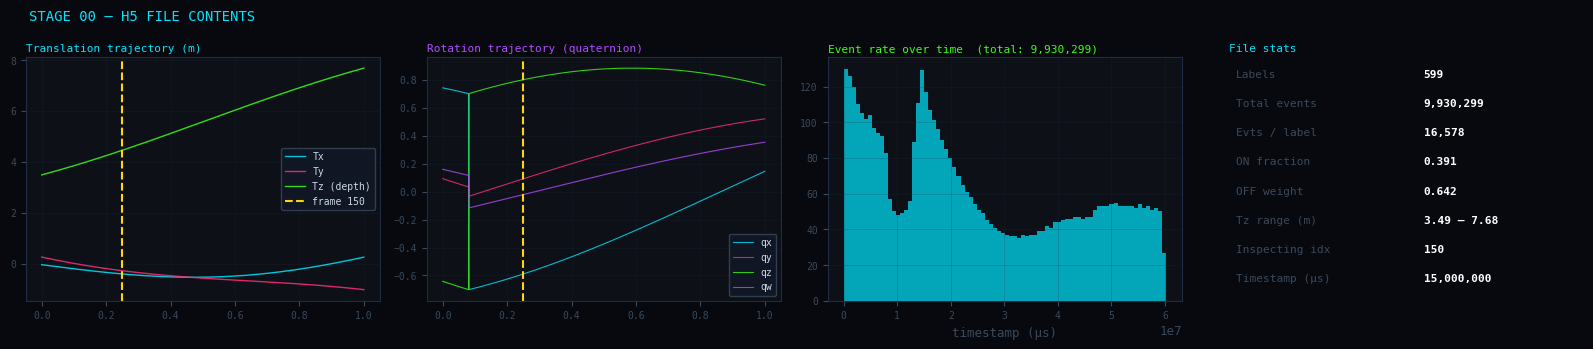

Label at frame 150:  T=(-0.4059, -0.2798, 4.4563)  q=(-0.5890, 0.0932, 0.8025, -0.0201)


In [4]:
with h5py.File(H5_FILE, 'r') as f:
    label_ts = f['labels/data']['timestamp'][:]
    tx = f['labels/data']['Tx'][:]; ty = f['labels/data']['Ty'][:]
    tz = f['labels/data']['Tz'][:]
    qx = f['labels/data']['Qx'][:]; qy = f['labels/data']['Qy'][:]
    qz = f['labels/data']['Qz'][:]; qw = f['labels/data']['Qw'][:]
    n_events_total = len(f['events/ts'])
    ps_sample = f['events/ps'][:500000]

p_on = np.mean(ps_sample)
off_weight = p_on / (1.0 - p_on + 1e-6)
n_labels = len(label_ts)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('STAGE 00 — H5 FILE CONTENTS', color=CYAN, fontsize=10, x=0.02, ha='left', fontfamily='monospace')
fig.patch.set_facecolor('#07090f')

# Translation trajectory
ax = axes[0]
t_vals = np.linspace(0, 1, n_labels)
ax.plot(t_vals, tx, color=CYAN,   lw=1, label='Tx', alpha=0.85)
ax.plot(t_vals, ty, color=PINK,   lw=1, label='Ty', alpha=0.85)
ax.plot(t_vals, tz, color=GREEN,  lw=1, label='Tz (depth)', alpha=0.85)
ax.axvline(FRAME_IDX/n_labels, color=YELLOW, lw=1.5, ls='--', label=f'frame {FRAME_IDX}')
ax.legend(fontsize=7, facecolor='#111827', edgecolor=DIM)
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, 'Translation trajectory (m)')

# Quaternion trajectory
ax = axes[1]
for vals, col, lbl in zip([qx,qy,qz,qw],[CYAN,PINK,GREEN,PURPLE],['qx','qy','qz','qw']):
    ax.plot(t_vals, vals, color=col, lw=0.8, label=lbl, alpha=0.8)
ax.axvline(FRAME_IDX/n_labels, color=YELLOW, lw=1.5, ls='--')
ax.legend(fontsize=7, facecolor='#111827', edgecolor=DIM)
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, 'Rotation trajectory (quaternion)', PURPLE)

# Event rate over time
ax = axes[2]
bin_edges = np.linspace(0, n_events_total, 200)
with h5py.File(H5_FILE, 'r') as f:
    ts_sample = f['events/ts'][::max(1, n_events_total//5000)]
ax.hist(ts_sample, bins=80, color=CYAN, alpha=0.7, edgecolor='none')
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, f'Event rate over time  (total: {n_events_total:,})', GREEN)
ax.set_xlabel('timestamp (μs)', color=DIM)

# Stats table
ax = axes[3]
ax.axis('off')
stats = [
    ['Labels',          f'{n_labels:,}'],
    ['Total events',    f'{n_events_total:,}'],
    ['Evts / label',    f'{n_events_total//n_labels:,}'],
    ['ON fraction',     f'{p_on:.3f}'],
    ['OFF weight',      f'{off_weight:.3f}'],
    ['Tz range (m)',    f'{tz.min():.2f} – {tz.max():.2f}'],
    ['Inspecting idx',  f'{FRAME_IDX}'],
    ['Timestamp (μs)',  f'{label_ts[FRAME_IDX]:,}'],
]
for i, (k, v) in enumerate(stats):
    ax.text(0.02, 0.95-i*0.12, k, transform=ax.transAxes, color=DIM, fontsize=8, va='top')
    ax.text(0.55, 0.95-i*0.12, v, transform=ax.transAxes, color='white', fontsize=8, va='top', fontweight='bold')
title_bar(ax, 'File stats')

plt.tight_layout()
plt.show()
print(f'Label at frame {FRAME_IDX}:  T=({tx[FRAME_IDX]:.4f}, {ty[FRAME_IDX]:.4f}, {tz[FRAME_IDX]:.4f})  '
      f'q=({qx[FRAME_IDX]:.4f}, {qy[FRAME_IDX]:.4f}, {qz[FRAME_IDX]:.4f}, {qw[FRAME_IDX]:.4f})')

---
## STAGE 1 — Load event window & Event Count Filter

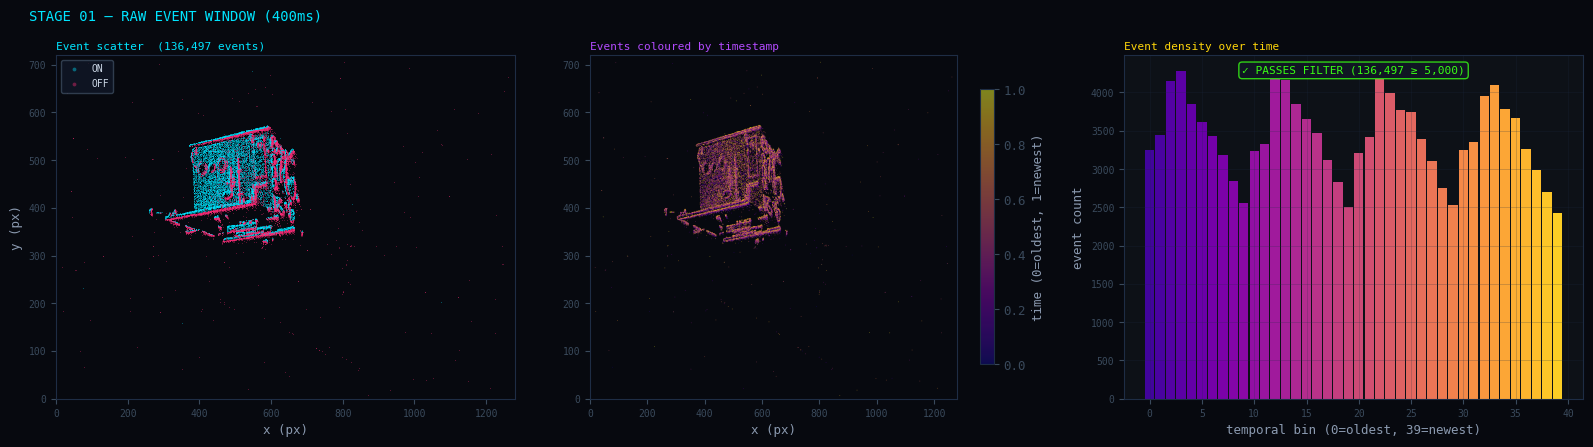

n_events=136,497  ON=78,780 (57.7%)  OFF=57,717


In [5]:
target_ts = label_ts[FRAME_IDX]

with h5py.File(H5_FILE, 'r') as f:
    ev_ts = f['events/ts'][:]
    idx_e = int(np.searchsorted(ev_ts, target_ts))
    idx_s = int(np.searchsorted(ev_ts, target_ts - WINDOW))
    xs_raw = f['events/xs'][idx_s:idx_e]
    ys_raw = f['events/ys'][idx_s:idx_e]
    ts_raw = ev_ts[idx_s:idx_e]
    ps_raw = f['events/ps'][idx_s:idx_e]

n_events = len(xs_raw)
MIN_EVENTS = 5000
passes_filter = n_events >= MIN_EVENTS

# Normalised time within window
t_norm = (ts_raw - ts_raw.min()) / max(ts_raw.max() - ts_raw.min(), 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('STAGE 01 — RAW EVENT WINDOW (400ms)', color=CYAN, fontsize=10, x=0.02, ha='left', fontfamily='monospace')
fig.patch.set_facecolor('#07090f')

# Scatter: x,y coloured by polarity
ax = axes[0]
subsample = min(30000, n_events)
idx_sub = np.random.choice(n_events, subsample, replace=False)
on_mask  = ps_raw[idx_sub] == 1
ax.scatter(xs_raw[idx_sub][on_mask],  720-ys_raw[idx_sub][on_mask],
           s=0.3, c=CYAN,  alpha=0.4, linewidths=0, rasterized=True, label='ON')
ax.scatter(xs_raw[idx_sub][~on_mask], 720-ys_raw[idx_sub][~on_mask],
           s=0.3, c=PINK, alpha=0.4, linewidths=0, rasterized=True, label='OFF')
ax.set_xlim(0, 1280); ax.set_ylim(0, 720)
ax.set_facecolor('#07090f'); dim_axes(ax)
ax.legend(fontsize=7, markerscale=5, facecolor='#111827', edgecolor=DIM)
title_bar(ax, f'Event scatter  ({n_events:,} events)')
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')

# Coloured by time
ax = axes[1]
sc = ax.scatter(xs_raw[idx_sub], 720-ys_raw[idx_sub],
                s=0.3, c=t_norm[idx_sub], cmap='plasma', alpha=0.5,
                linewidths=0, rasterized=True)
plt.colorbar(sc, ax=ax, label='time (0=oldest, 1=newest)', shrink=0.8)
ax.set_xlim(0, 1280); ax.set_ylim(0, 720)
ax.set_facecolor('#07090f'); dim_axes(ax)
title_bar(ax, 'Events coloured by timestamp', PURPLE)
ax.set_xlabel('x (px)')

# Event count filter check + temporal histogram
ax = axes[2]
n_bins_hist = 40
counts, bin_edges = np.histogram(t_norm, bins=n_bins_hist)
colours = plt.cm.plasma(np.linspace(0.1, 0.9, n_bins_hist))
ax.bar(range(n_bins_hist), counts, color=colours, edgecolor='none', width=0.9)
ax.set_xlabel('temporal bin (0=oldest, 39=newest)')
ax.set_ylabel('event count')
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, 'Event density over time', YELLOW)

status_col = GREEN if passes_filter else PINK
status_txt = f'✓ PASSES FILTER ({n_events:,} ≥ {MIN_EVENTS:,})' if passes_filter \
             else f'✗ WOULD BE SKIPPED ({n_events:,} < {MIN_EVENTS:,})'
ax.text(0.5, 0.97, status_txt, transform=ax.transAxes, color=status_col,
        fontsize=8, ha='center', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#111827', edgecolor=status_col, alpha=0.8))

plt.tight_layout()
plt.show()
print(f'n_events={n_events:,}  ON={ps_raw.sum():,} ({100*ps_raw.mean():.1f}%)  OFF={(~ps_raw.astype(bool)).sum():,}')

---
## STAGE 2 — Density Centroid: finding the satellite

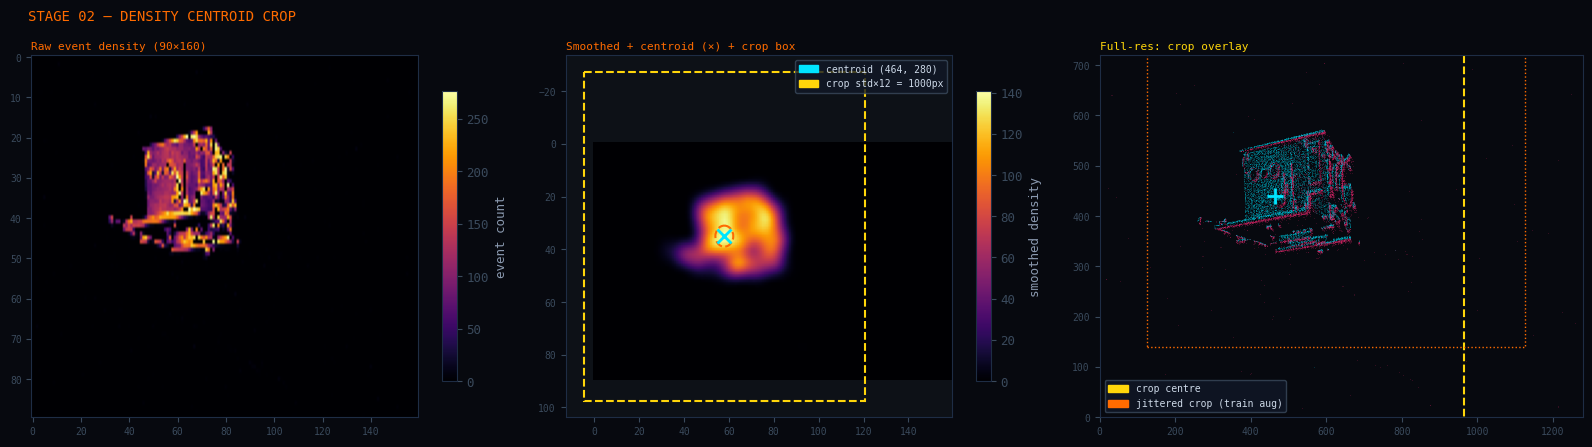

Centroid: (464.0, 280.0)  |  std_crop: 1000.0px  |  scale_hint: 0.7812


In [6]:
# ── Build density map and find centroid ──────────────────────────────────────
DOWNSAMPLE = 8
dH, dW = 720 // DOWNSAMPLE, 1280 // DOWNSAMPLE
density = np.zeros((dH, dW), dtype=np.float32)

xi_d = np.clip(xs_raw // DOWNSAMPLE, 0, dW-1)
yi_d = np.clip(ys_raw // DOWNSAMPLE, 0, dH-1)
np.add.at(density, (yi_d, xi_d), 1)

# Remove hot pixels (defective sensor pixels spike at huge counts)
hot_thresh = np.percentile(density, 99.5)
hot_mask = density > hot_thresh
density[hot_mask] = 0.0

density_t = torch.from_numpy(density).unsqueeze(0)
density_smooth = TF.gaussian_blur(density_t, kernel_size=[13,13], sigma=[3.0,3.0]).squeeze(0).numpy()

if density_smooth.max() > 1e-6:
    py, px = np.unravel_index(density_smooth.argmax(), density_smooth.shape)
    cx_found = float(px * DOWNSAMPLE)
    cy_found = float(py * DOWNSAMPLE)
else:
    cx_found, cy_found = 640.0, 360.0

# Crop size
std_crop = float(np.clip(max(np.std(xs_raw), np.std(ys_raw)) * 12.0, 300, 1000))

# Training jitter (simulate what __getitem__ does)
cx_jit = cx_found + np.random.uniform(-std_crop*0.25, std_crop*0.25)
cy_jit = cy_found + np.random.uniform(-std_crop*0.25, std_crop*0.25)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('STAGE 02 — DENSITY CENTROID CROP', color=ORANGE, fontsize=10, x=0.02, ha='left', fontfamily='monospace')
fig.patch.set_facecolor('#07090f')

# Raw density (downsampled)
ax = axes[0]
im = ax.imshow(density, cmap='inferno', aspect='auto', origin='upper')
plt.colorbar(im, ax=ax, shrink=0.8, label='event count')
ax.set_title(f'Raw event density ({dH}×{dW})', color=ORANGE, fontsize=8, pad=4, loc='left')
dim_axes(ax)

# Smoothed + centroid
ax = axes[1]
im = ax.imshow(density_smooth, cmap='inferno', aspect='auto', origin='upper')
plt.colorbar(im, ax=ax, shrink=0.8, label='smoothed density')
# Mark centroid
ax.plot(px, py, 'x', color=CYAN, markersize=10, markeredgewidth=2)
ax.add_patch(mpatches.Circle((px, py), radius=4, fill=False, edgecolor=ORANGE, linewidth=1.5, linestyle='--'))
# Crop box in density coords
half = (std_crop/2) / DOWNSAMPLE
rect = mpatches.Rectangle((px-half, py-half), half*2, half*2,
                            fill=False, edgecolor=YELLOW, linewidth=1.5, linestyle='--')
ax.add_patch(rect)
ax.set_title('Smoothed + centroid (×) + crop box', color=ORANGE, fontsize=8, pad=4, loc='left')
ax.legend(handles=[
    mpatches.Patch(color=CYAN,   label=f'centroid ({cx_found:.0f}, {cy_found:.0f})'),
    mpatches.Patch(color=YELLOW, label=f'crop std×12 = {std_crop:.0f}px'),
], fontsize=7, facecolor='#111827', edgecolor=DIM)
dim_axes(ax)

# Full-res scatter with crop overlay
ax = axes[2]
idx_sub2 = np.random.choice(n_events, min(20000, n_events), replace=False)
on_m  = ps_raw[idx_sub2] == 1
ax.scatter(xs_raw[idx_sub2][on_m],   720-ys_raw[idx_sub2][on_m],
           s=0.2, c=CYAN, alpha=0.3, linewidths=0, rasterized=True)
ax.scatter(xs_raw[idx_sub2][~on_m],  720-ys_raw[idx_sub2][~on_m],
           s=0.2, c=PINK, alpha=0.3, linewidths=0, rasterized=True)
# Centroid
ax.plot(cx_found, 720-cy_found, '+', color=CYAN, markersize=12, markeredgewidth=2)
# Crop box
h_s = std_crop / 2
rect2 = mpatches.Rectangle((cx_found-h_s, (720-cy_found)-h_s), std_crop, std_crop,
                             fill=False, edgecolor=YELLOW, linewidth=1.5, linestyle='--')
ax.add_patch(rect2)
# Jittered crop
rect3 = mpatches.Rectangle((cx_jit-h_s, (720-cy_jit)-h_s), std_crop, std_crop,
                             fill=False, edgecolor=ORANGE, linewidth=1.0, linestyle=':')
ax.add_patch(rect3)
ax.set_xlim(0,1280); ax.set_ylim(0,720)
ax.set_facecolor('#07090f'); dim_axes(ax)
ax.legend(handles=[
    mpatches.Patch(color=YELLOW, label='crop centre'),
    mpatches.Patch(color=ORANGE, label='jittered crop (train aug)'),
], fontsize=7, facecolor='#111827', edgecolor=DIM)
title_bar(axes[2], 'Full-res: crop overlay', YELLOW)

plt.tight_layout()
plt.show()
print(f'Centroid: ({cx_found:.1f}, {cy_found:.1f})  |  std_crop: {std_crop:.1f}px  |  scale_hint: {std_crop/1280:.4f}')

---
## STAGE 3 — 18-Channel Voxel Grid

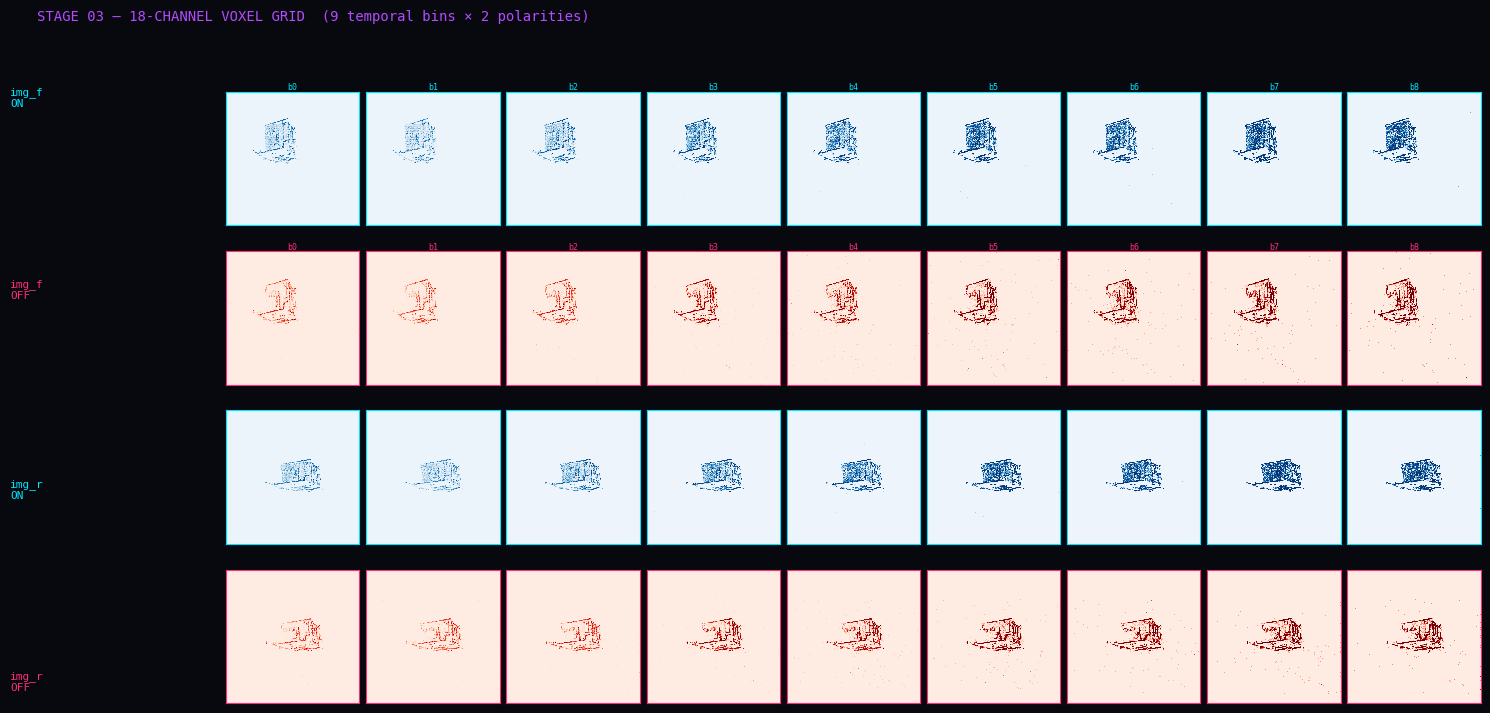

img_f  shape: (18, 320, 320)  max: 1.0000  mean: 0.0716  nonzero: 1.000
img_r  shape: (18, 320, 320)  max: 1.0000  mean: 0.0710  nonzero: 1.000
scale_hint: 0.7812  (= std_crop/1280 = 1000/1280)


In [7]:
def create_voxel_tensor(xs, ys, ts, ps, target_ts, window, off_weight, crop_box=None):
    img = np.zeros((N_CH, RES, RES), dtype=np.float32)
    if len(xs) < 5:
        return torch.from_numpy(img).float(), 1.0

    weights = np.clip(1.0 - (target_ts - ts) / window, 0.2, 1.0)

    if crop_box:
        cx, cy, sz = crop_box
        sz = max(sz, 10.0)
        scale_hint = sz / 1280.0
        xi = np.clip((xs - (cx - sz/2)) * (RES/sz), 0, RES-1).astype(int)
        yi = np.clip((ys - (cy - sz/2)) * (RES/sz), 0, RES-1).astype(int)
    else:
        scale_hint = 1.0
        xi = np.clip(xs * ((RES-1)/1280), 0, RES-1).astype(int)
        yi = np.clip(ys * ((RES-1)/720),  0, RES-1).astype(int)

    t0, t1 = ts[0], ts[-1]
    t_range = max(t1 - t0, 1.0)
    bin_idx = np.clip(((ts - t0) / t_range * T_BINS).astype(int), 0, T_BINS-1)

    for b in range(T_BINS):
        m_on  = (bin_idx == b) & (ps == 1)
        m_off = (bin_idx == b) & (ps == 0)
        if m_on.any():  np.add.at(img[b],          (yi[m_on],  xi[m_on]),  weights[m_on])
        if m_off.any(): np.add.at(img[T_BINS + b], (yi[m_off], xi[m_off]), weights[m_off] * off_weight)

    tensor  = torch.from_numpy(img).unsqueeze(0)
    dilated = F.pad(F.max_pool2d(tensor, 2, 1, 0), (0,1,0,1))
    blur_k  = torch.ones((1,1,3,3)) / 9.0
    for ch in range(N_CH):
        blurred = F.conv2d(dilated[:, ch:ch+1], blur_k, padding=1)
        dilated[:, ch:ch+1] = dilated[:, ch:ch+1] + 0.8*(dilated[:, ch:ch+1]-blurred)

    out = dilated.squeeze(0).numpy()
    log_img = np.log1p(np.clip(out, 0, None))
    for grp in [slice(0, T_BINS), slice(T_BINS, N_CH)]:
        g_max = np.max(log_img[grp]) + 1e-9
        if g_max > 1e-7:
            log_img[grp] = 1.0 / (1.0 + np.exp(-10.0*(log_img[grp]/g_max - 0.3)))
            p99 = np.percentile(log_img[grp], 99.5) + 1e-8
            log_img[grp] = np.clip(log_img[grp] / p99, 0, 1)

    return torch.from_numpy(log_img).float(), float(scale_hint)

xs, ys, ts_ev, ps = xs_raw, ys_raw, ts_raw, ps_raw
img_f, _ = create_voxel_tensor(xs, ys, ts_ev, ps, target_ts, WINDOW, off_weight)
img_r, sc = create_voxel_tensor(xs, ys, ts_ev, ps, target_ts, WINDOW, off_weight,
                                 crop_box=(cx_found, cy_found, std_crop))

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('#07090f')
fig.suptitle('STAGE 03 — 18-CHANNEL VOXEL GRID  (9 temporal bins × 2 polarities)', 
             color=PURPLE, fontsize=10, x=0.02, ha='left', fontfamily='monospace')

gs = gridspec.GridSpec(4, 10, hspace=0.15, wspace=0.05, figure=fig)

# Full frame: show all 18 channels as strips
for ch in range(N_CH):
    row = ch // 10
    col = ch % 10
    if row < 2:  # first 2 rows = img_f
        data = img_f[ch].numpy()
        cmap = 'Blues'   if ch < T_BINS else 'Reds'
        border_col = CYAN if ch < T_BINS else PINK
    else:
        data = img_r[ch - N_CH if ch >= N_CH else ch].numpy()
        # skip — handled below
        continue

# Cleaner layout: 2 rows of full-frame, 2 rows of crop
# Row 0-1: img_f ON and OFF
for ch in range(N_CH):
    row = 0 if ch < T_BINS else 1
    col = ch if ch < T_BINS else ch - T_BINS
    ax = fig.add_subplot(gs[row, col])
    data = img_f[ch].numpy()
    cmap = 'Blues' if ch < T_BINS else 'Reds'
    ax.imshow(data, cmap=cmap, vmin=0, vmax=data.max()+1e-6, aspect='equal', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): 
        spine.set_edgecolor(CYAN if ch < T_BINS else PINK)
        spine.set_linewidth(0.8)
    ax.set_title(f'b{ch%T_BINS}', color=CYAN if ch<T_BINS else PINK, fontsize=6, pad=1)

# Row 2-3: img_r (cropped) ON and OFF
for ch in range(N_CH):
    row = 2 if ch < T_BINS else 3
    col = ch if ch < T_BINS else ch - T_BINS
    ax = fig.add_subplot(gs[row, col])
    data = img_r[ch].numpy()
    cmap = 'Blues' if ch < T_BINS else 'Reds'
    ax.imshow(data, cmap=cmap, vmin=0, vmax=data.max()+1e-6, aspect='equal', interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(CYAN if ch < T_BINS else PINK)
        spine.set_linewidth(0.8)

# Row labels
fig.text(0.005, 0.87, 'img_f\nON', color=CYAN, fontsize=8, va='center', fontfamily='monospace')
fig.text(0.005, 0.63, 'img_f\nOFF', color=PINK, fontsize=8, va='center', fontfamily='monospace')
fig.text(0.005, 0.38, 'img_r\nON', color=CYAN, fontsize=8, va='center', fontfamily='monospace')
fig.text(0.005, 0.14, 'img_r\nOFF', color=PINK, fontsize=8, va='center', fontfamily='monospace')

plt.show()

# Summary stats
print(f'img_f  shape: {tuple(img_f.shape)}  max: {img_f.max():.4f}  mean: {img_f.mean():.4f}  nonzero: {(img_f>0.05).float().mean():.3f}')
print(f'img_r  shape: {tuple(img_r.shape)}  max: {img_r.max():.4f}  mean: {img_r.mean():.4f}  nonzero: {(img_r>0.05).float().mean():.3f}')
print(f'scale_hint: {sc:.4f}  (= std_crop/1280 = {std_crop:.0f}/1280)')

---
## STAGE 3b — Voxel Side-by-Side: Full Frame vs Cropped (RGB composite)

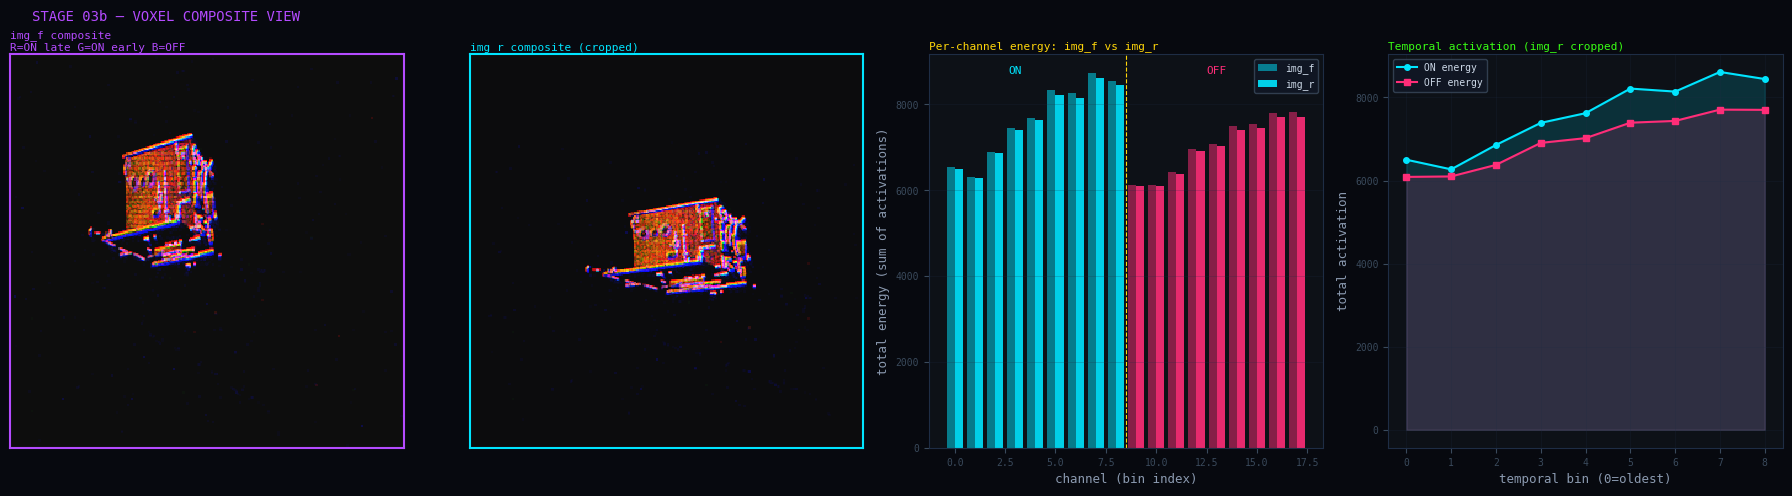

In [8]:
# Composite RGB: R=ON_early, G=ON_late, B=OFF (for quick visual)
def voxel_to_rgb(vox):
    on_early = vox[:3].mean(0).numpy()
    on_late  = vox[6:9].mean(0).numpy()
    off_mid  = vox[12:15].mean(0).numpy()
    rgb = np.stack([on_late, on_early, off_mid], axis=-1)
    rgb = rgb / (rgb.max() + 1e-6)
    return np.clip(rgb, 0, 1)

def per_channel_energy(vox):
    return [vox[ch].numpy().sum() for ch in range(N_CH)]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor('#07090f')
fig.suptitle('STAGE 03b — VOXEL COMPOSITE VIEW', color=PURPLE, fontsize=10, x=0.02, ha='left', fontfamily='monospace')

ax = axes[0]
ax.imshow(voxel_to_rgb(img_f), aspect='equal', interpolation='nearest')
ax.set_title('img_f composite\nR=ON_late G=ON_early B=OFF', color=PURPLE, fontsize=8, pad=3, loc='left')
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_edgecolor(PURPLE); sp.set_linewidth(1.5)

ax = axes[1]
ax.imshow(voxel_to_rgb(img_r), aspect='equal', interpolation='nearest')
ax.set_title('img_r composite (cropped)', color=CYAN, fontsize=8, pad=3, loc='left')
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_edgecolor(CYAN); sp.set_linewidth(1.5)

# Per-channel energy
ax = axes[2]
energy_f = per_channel_energy(img_f)
energy_r = per_channel_energy(img_r)
x_pos = np.arange(N_CH)
colours = [CYAN]*T_BINS + [PINK]*T_BINS
ax.bar(x_pos - 0.2, energy_f, width=0.4, color=colours, alpha=0.5, label='img_f')
ax.bar(x_pos + 0.2, energy_r, width=0.4, color=colours, alpha=0.9, label='img_r')
ax.axvline(8.5, color=YELLOW, lw=0.8, ls='--')
ax.text(3, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1]>0 else 1, 'ON', color=CYAN, ha='center', fontsize=8)
ax.text(13, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1]>0 else 1, 'OFF', color=PINK, ha='center', fontsize=8)
ax.set_xlabel('channel (bin index)')
ax.set_ylabel('total energy (sum of activations)')
ax.legend(fontsize=7, facecolor='#111827', edgecolor=DIM)
ax.grid(True, alpha=0.3, axis='y'); dim_axes(ax)
title_bar(ax, 'Per-channel energy: img_f vs img_r', YELLOW)

# Temporal ON vs OFF ratio
ax = axes[3]
on_energy  = [img_r[b].numpy().sum() for b in range(T_BINS)]
off_energy = [img_r[T_BINS+b].numpy().sum() for b in range(T_BINS)]
bins_x = np.arange(T_BINS)
ax.plot(bins_x, on_energy,  color=CYAN,  marker='o', ms=4, lw=1.5, label='ON energy')
ax.plot(bins_x, off_energy, color=PINK,  marker='s', ms=4, lw=1.5, label='OFF energy')
ax.fill_between(bins_x, on_energy,  alpha=0.15, color=CYAN)
ax.fill_between(bins_x, off_energy, alpha=0.15, color=PINK)
ax.set_xlabel('temporal bin (0=oldest)')
ax.set_ylabel('total activation')
ax.legend(fontsize=7, facecolor='#111827', edgecolor=DIM)
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, 'Temporal activation (img_r cropped)', GREEN)

plt.tight_layout()
plt.show()

---
## STAGE 4 — Optical Flow (2 channels via time-surface gradient)

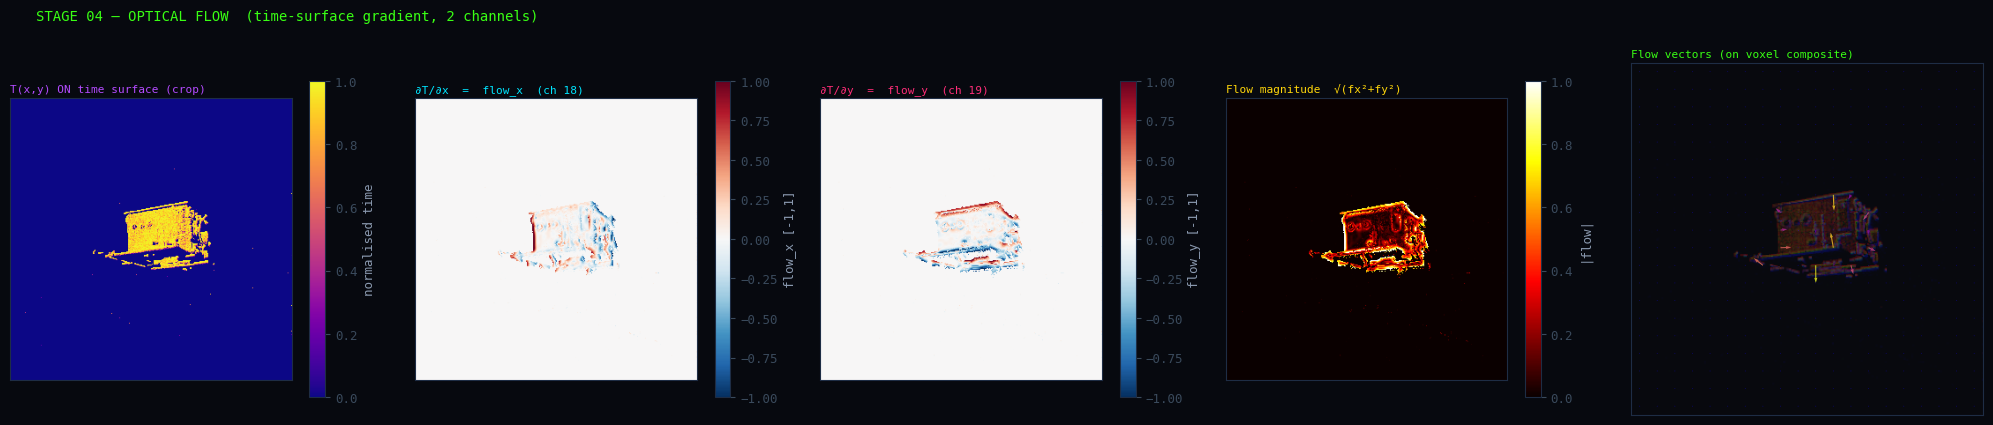

flow_r  shape: (2, 320, 320)  |  active pixels: 5.0%  |  max_mag: 1.3376


In [9]:
def compute_flow(xs, ys, ts_e, ps, target_ts, window, crop_box=None):
    if len(xs) < 10:
        return np.zeros((2, RES, RES), dtype=np.float32)

    if crop_box:
        cx, cy, sz = crop_box
        sz = max(sz, 10.0)
        xi = np.clip((xs - (cx - sz/2)) * (RES/sz), 0, RES-1).astype(int)
        yi = np.clip((ys - (cy - sz/2)) * (RES/sz), 0, RES-1).astype(int)
    else:
        xi = np.clip(xs * ((RES-1)/1280), 0, RES-1).astype(int)
        yi = np.clip(ys * ((RES-1)/720),  0, RES-1).astype(int)

    t_norm = (ts_e - ts_e.min()) / max(ts_e.max() - ts_e.min(), 1.0)
    T_on  = np.zeros((RES, RES), dtype=np.float32)
    T_off = np.zeros((RES, RES), dtype=np.float32)
    cnt_on  = np.zeros((RES, RES), dtype=np.int32)
    cnt_off = np.zeros((RES, RES), dtype=np.int32)

    sort_order = np.argsort(t_norm)
    xi_s, yi_s = xi[sort_order], yi[sort_order]
    tn_s, ps_s = t_norm[sort_order], ps[sort_order]
    m_on  = ps_s == 1; m_off = ~m_on

    np.add.at(cnt_on,  (yi_s[m_on],  xi_s[m_on]),  1)
    np.add.at(cnt_off, (yi_s[m_off], xi_s[m_off]), 1)
    np.maximum.at(T_on,  (yi_s[m_on],  xi_s[m_on]),  tn_s[m_on])
    np.maximum.at(T_off, (yi_s[m_off], xi_s[m_off]), tn_s[m_off])

    gx_comb = np.zeros((RES,RES), dtype=np.float32)
    gy_comb = np.zeros((RES,RES), dtype=np.float32)
    weight_sum = np.zeros((RES,RES), dtype=np.float32)
    reliable = np.zeros((RES,RES), dtype=bool)

    for T_surf, cnt in [(T_on, cnt_on), (T_off, cnt_off)]:
        has_ev = cnt >= 2
        if not has_ev.any(): continue
        T_s = TF.gaussian_blur(torch.from_numpy(T_surf).unsqueeze(0), [9,9], [2.0,2.0]).squeeze(0).numpy()
        gy, gx = np.gradient(T_s)
        w = np.clip(cnt.astype(float)/3.0, 0, 1) * has_ev
        gx_comb += gx * w; gy_comb += gy * w; weight_sum += w
        reliable |= has_ev

    safe_w = np.where(weight_sum > 0, weight_sum, 1.0)
    gx_avg = gx_comb / safe_w; gy_avg = gy_comb / safe_w
    gx_avg[~reliable] = 0.0;   gy_avg[~reliable] = 0.0

    mag = np.abs(np.stack([gx_avg[reliable], gy_avg[reliable]])) if reliable.any() else np.array([1.0])
    scale = np.percentile(mag, 99) + 1e-6
    return np.stack([np.clip(gx_avg/scale, -1, 1), np.clip(gy_avg/scale, -1, 1)]).astype(np.float32)

flow_f = compute_flow(xs, ys, ts_ev, ps, target_ts, WINDOW)
flow_r = compute_flow(xs, ys, ts_ev, ps, target_ts, WINDOW, crop_box=(cx_found, cy_found, std_crop))

# Time surface for visualisation
T_on_vis  = np.zeros((RES,RES), dtype=np.float32)
xi_r = np.clip((xs - (cx_found - std_crop/2)) * (RES/std_crop), 0, RES-1).astype(int)
yi_r = np.clip((ys - (cy_found - std_crop/2)) * (RES/std_crop), 0, RES-1).astype(int)
t_n = (ts_ev - ts_ev.min()) / max(ts_ev.max()-ts_ev.min(), 1.0)
m_on_all = ps == 1
sort_ord = np.argsort(t_n)
np.maximum.at(T_on_vis, (yi_r[sort_ord][m_on_all[sort_ord]], xi_r[sort_ord][m_on_all[sort_ord]]),
              t_n[sort_ord][m_on_all[sort_ord]])

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
fig.patch.set_facecolor('#07090f')
fig.suptitle('STAGE 04 — OPTICAL FLOW  (time-surface gradient, 2 channels)', 
             color=GREEN, fontsize=10, x=0.02, ha='left', fontfamily='monospace')

ax = axes[0]
im = ax.imshow(T_on_vis, cmap='plasma', aspect='equal', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='normalised time')
title_bar(ax, 'T(x,y) ON time surface (crop)', PURPLE)
ax.set_xticks([]); ax.set_yticks([])

ax = axes[1]
im = ax.imshow(flow_r[0], cmap='RdBu_r', aspect='equal', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='flow_x [-1,1]')
title_bar(ax, '∂T/∂x  =  flow_x  (ch 18)', CYAN)
ax.set_xticks([]); ax.set_yticks([])

ax = axes[2]
im = ax.imshow(flow_r[1], cmap='RdBu_r', aspect='equal', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='flow_y [-1,1]')
title_bar(ax, '∂T/∂y  =  flow_y  (ch 19)', PINK)
ax.set_xticks([]); ax.set_yticks([])

# Flow magnitude
ax = axes[3]
mag_map = np.sqrt(flow_r[0]**2 + flow_r[1]**2)
im = ax.imshow(mag_map, cmap='hot', aspect='equal', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='|flow|')
title_bar(ax, 'Flow magnitude  √(fx²+fy²)', YELLOW)
ax.set_xticks([]); ax.set_yticks([])

# Flow as quiver (downsampled)
ax = axes[4]
ax.set_facecolor('#07090f')
step = 16
y_q, x_q = np.mgrid[step//2:RES:step, step//2:RES:step]
u = flow_r[0][y_q, x_q]
v = flow_r[1][y_q, x_q]
mag_q = np.sqrt(u**2 + v**2)
ax.quiver(x_q, y_q, u, -v, mag_q, cmap='plasma', scale=20, width=0.003, alpha=0.8)
ax.imshow(voxel_to_rgb(img_r), aspect='equal', alpha=0.25, extent=[0,RES,RES,0])
ax.set_xlim(0, RES); ax.set_ylim(RES, 0)
ax.set_xticks([]); ax.set_yticks([])
dim_axes(ax)
title_bar(ax, 'Flow vectors (on voxel composite)', GREEN)

plt.tight_layout()
plt.show()

flow_active = (mag_map > 0.05).mean()
print(f'flow_r  shape: {flow_r.shape}  |  active pixels: {flow_active:.1%}  |  max_mag: {mag_map.max():.4f}')

---
## STAGE 5 — Augmentation Suite (all 10 augmentations applied and shown)

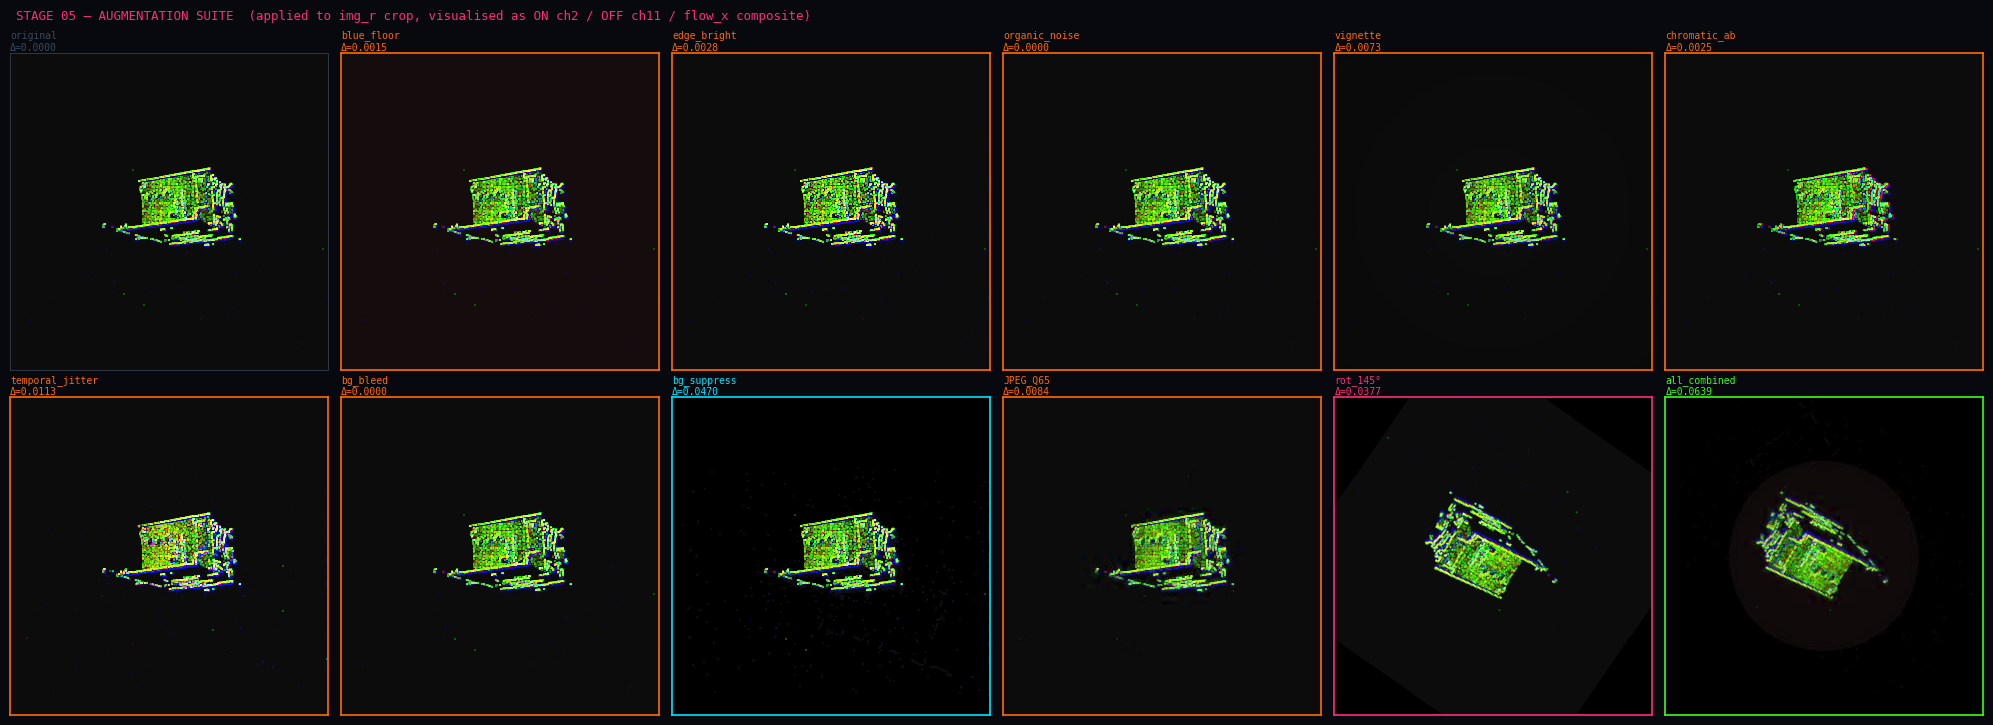

In [10]:
# Copy the full augmentation pipeline from spades_v35_v3.py
def step_blue_floor_vox(t):
    bias = torch.zeros_like(t)
    for b in range(T_BINS): bias[b] = random.uniform(0.00, 0.02) * (1.0 - b*0.03)
    bias[2]=random.uniform(0.06,0.10); bias[1]=random.uniform(0.01,0.04)
    bias[T_BINS+2]=random.uniform(0.01,0.04); bias[T_BINS+1]=random.uniform(0.00,0.02)
    return torch.max(t, bias)

def step_edge_bright_vox(t):
    k = torch.tensor([[1,2,1],[2,4,2],[1,2,1]],dtype=torch.float32)/16.0
    kk = k.view(1,1,3,3); boost=random.uniform(0.4,0.7)
    bright_mask=(t.max(0,keepdim=True)[0]>0.35).float(); out=t.clone()
    for ch in range(N_CH):
        padded=F.pad(out[ch:ch+1].unsqueeze(0),(1,1,1,1),mode='reflect')
        blurred=F.conv2d(padded,kk,padding=0).squeeze(0)
        out[ch:ch+1]=torch.clamp(out[ch:ch+1]+(out[ch:ch+1]-blurred)*bright_mask*boost,0,1)
    return out

def step_organic_noise_vox(t):
    c,h,w=t.shape
    density=F.interpolate(torch.rand(1,1,h//4,w//4),(h,w),mode='bilinear',align_corners=False).squeeze(0)
    void_mask=(t.max(0,keepdim=True)[0]<0.2).float()
    salt_mask=((torch.rand(1,h,w)*density)>0.98)&(void_mask>0.5)
    n=int(salt_mask.sum()); noise=torch.zeros_like(t)
    if n>0:
        for b in [0,T_BINS//2,T_BINS-1]: noise[b,salt_mask[0]]=torch.rand(n)*random.uniform(0.3,0.75)
    return torch.clamp(t+noise,0,1)

def step_vignette_vox(t):
    c,h,w=t.shape
    y=torch.linspace(-1,1,h).view(h,1); x=torch.linspace(-1,1,w).view(1,w)
    vig=torch.clamp(1.0-torch.sqrt(x**2+y**2)*random.uniform(0.10,0.28),0.55,1.0)
    return torch.clamp(t*vig,0,1)

def step_chromatic_ab_vox(t):
    shift=random.randint(1,2); out=t.clone()
    out[0]=torch.roll(t[0],-shift,dims=1); out[2]=torch.roll(t[2],shift,dims=1)
    out[T_BINS]=torch.roll(t[T_BINS],-shift,dims=1); out[T_BINS+2]=torch.roll(t[T_BINS+2],shift,dims=1)
    return out

def step_temporal_jitter_vox(t):
    shift=random.choice([-1,1]); out=t.clone()
    out[0:T_BINS]=torch.roll(t[0:T_BINS],shift,dims=0)
    out[T_BINS:N_CH]=torch.roll(t[T_BINS:N_CH],shift,dims=0)
    return out

def step_jpeg_vox(t, quality=None):
    if quality is None: quality=random.randint(60,78)
    out=t.clone()
    for start in range(0,N_CH,3):
        group=t[start:start+3]
        np_img=(group.permute(1,2,0).numpy()*255).clip(0,255).astype(np.uint8)
        buf=io.BytesIO(); Image.fromarray(np_img).save(buf,format='JPEG',quality=quality)
        buf.seek(0)
        out[start:start+3]=torch.from_numpy(np.array(Image.open(buf)).astype(np.float32)/255.0).permute(2,0,1)
    return out

def step_bg_bleed_vox(t):
    c,h,w=t.shape
    y,x=torch.meshgrid(torch.arange(h),torch.arange(w),indexing='ij')
    angle=random.uniform(-45,45); cx_pos=random.randint(w//4,3*w//4)
    dist=torch.abs((x.float()-cx_pos)*math.cos(math.radians(angle))-(y.float()-h//2)*math.sin(math.radians(angle)))
    streak=torch.exp(-dist/0.7)*random.uniform(0.05,0.12)
    void_mask=(t.max(0)[0]<0.12).float(); out=t.clone()
    out[T_BINS-1]=torch.clamp(out[T_BINS-1]+streak*void_mask,0,1)
    out[N_CH-1]=torch.clamp(out[N_CH-1]+streak*void_mask*0.6,0,1)
    return out

def step_bg_suppression(t):
    threshold=random.uniform(0.05,0.10)
    bg_mask=(t.max(dim=0).values<threshold); out=t.clone(); out[:,bg_mask]=0.0
    return out

def step_in_plane_rotate(t, theta_deg):
    return TF.rotate(t, theta_deg, interpolation=TF.InterpolationMode.BILINEAR, expand=False)

# Apply all augmentations to img_r and show results
random.seed(99); torch.manual_seed(99)
base = img_r.clone()
theta = random.uniform(0, 360)

augmented_versions = [
    ('original',       base),
    ('blue_floor',     step_blue_floor_vox(base.clone())),
    ('edge_bright',    step_edge_bright_vox(base.clone())),
    ('organic_noise',  step_organic_noise_vox(base.clone())),
    ('vignette',       step_vignette_vox(base.clone())),
    ('chromatic_ab',   step_chromatic_ab_vox(base.clone())),
    ('temporal_jitter',step_temporal_jitter_vox(base.clone())),
    ('bg_bleed',       step_bg_bleed_vox(base.clone())),
    ('bg_suppress',    step_bg_suppression(base.clone())),
    ('JPEG_Q65',       step_jpeg_vox(base.clone(), quality=65)),
    (f'rot_{theta:.0f}°', step_in_plane_rotate(base.clone(), theta)),
    ('all_combined',   step_jpeg_vox(step_in_plane_rotate(step_bg_suppression(step_vignette_vox(step_organic_noise_vox(step_blue_floor_vox(base.clone())))), theta), quality=70)),
]

fig, axes = plt.subplots(2, 6, figsize=(20, 7.5))
fig.patch.set_facecolor('#07090f')
fig.suptitle('STAGE 05 — AUGMENTATION SUITE  (applied to img_r crop, visualised as ON ch2 / OFF ch11 / flow_x composite)', 
             color=PINK, fontsize=9, x=0.01, ha='left', fontfamily='monospace')

highlight = {'original': DIM, 'rot_{}°'.format(int(theta)): PINK,
             'all_combined': GREEN, 'bg_suppress': CYAN}

for idx, (name, t) in enumerate(augmented_versions):
    ax = axes[idx // 6][idx % 6]
    # Composite: R=ON_bin2, G=ON_bin5, B=OFF_bin11
    r_ch = t[2].numpy()
    g_ch = t[5].numpy()
    b_ch = t[11].numpy()
    rgb = np.stack([r_ch, g_ch, b_ch], axis=-1)
    rgb = rgb / (rgb.max() + 1e-6)
    ax.imshow(np.clip(rgb, 0, 1), aspect='equal', interpolation='nearest')
    diff = (t - base).abs().mean().item()
    col = highlight.get(name, ORANGE)
    ax.set_title(f'{name}\nΔ={diff:.4f}', color=col, fontsize=7, pad=2, loc='left')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(1.2 if col!=DIM else 0.5)

plt.tight_layout()
plt.show()

---
## STAGE 5b — In-Plane Rotation: pose label update verification

TypeError: subplot_spec must be type SubplotSpec, usually from GridSpec, or axes.get_subplotspec.

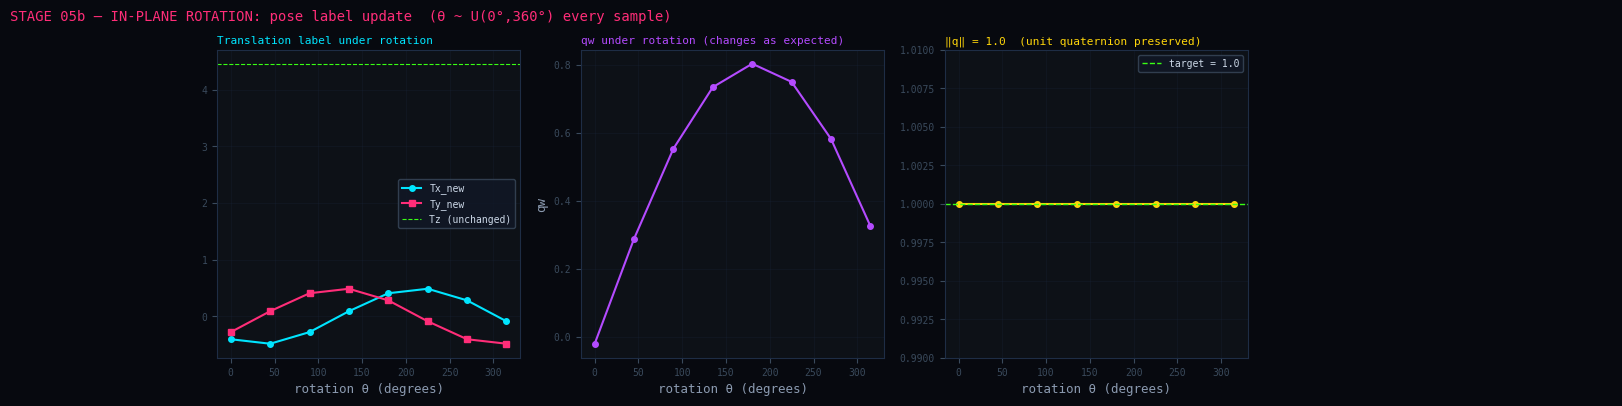

In [11]:
def rotate_pose_label(tx_v, ty_v, tz_v, qx_v, qy_v, qz_v, qw_v, theta_deg):
    th = math.radians(theta_deg)
    c, s = math.cos(th), math.sin(th)
    tx_n =  c*tx_v + s*ty_v
    ty_n = -s*tx_v + c*ty_v
    tz_n = tz_v
    th2 = th / 2
    c2, s2 = math.cos(th2), math.sin(th2)
    qx_n =  c2*qx_v + s2*qy_v
    qy_n = -s2*qx_v + c2*qy_v
    qz_n =  c2*qz_v - s2*qw_v
    qw_n =  s2*qz_v + c2*qw_v
    norm = math.sqrt(qx_n**2+qy_n**2+qz_n**2+qw_n**2)+1e-8
    return tx_n,ty_n,tz_n, qx_n/norm,qy_n/norm,qz_n/norm,qw_n/norm

tx_orig  = float(tx[FRAME_IDX]);  ty_orig  = float(ty[FRAME_IDX]);  tz_orig  = float(tz[FRAME_IDX])
qx_orig  = float(qx[FRAME_IDX]); qy_orig  = float(qy[FRAME_IDX]); qz_orig  = float(qz[FRAME_IDX]); qw_orig = float(qw[FRAME_IDX])

thetas = [0, 45, 90, 135, 180, 225, 270, 315]
results = []
for th in thetas:
    rotated = rotate_pose_label(tx_orig,ty_orig,tz_orig,qx_orig,qy_orig,qz_orig,qw_orig,th)
    tx_r,ty_r,tz_r,qx_r,qy_r,qz_r,qw_r = rotated
    q_norm = math.sqrt(qx_r**2+qy_r**2+qz_r**2+qw_r**2)
    results.append({'theta':th,'tx':tx_r,'ty':ty_r,'tz':tz_r,'qw':qw_r,'norm':q_norm})

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#07090f')
fig.suptitle('STAGE 05b — IN-PLANE ROTATION: pose label update  (θ ~ U(0°,360°) every sample)', 
             color=PINK, fontsize=10, x=0.01, ha='left', fontfamily='monospace')

thetas_arr = [r['theta'] for r in results]
ax = axes[0]
ax.plot(thetas_arr, [r['tx'] for r in results], color=CYAN,   marker='o', ms=4, lw=1.5, label='Tx_new')
ax.plot(thetas_arr, [r['ty'] for r in results], color=PINK,   marker='s', ms=4, lw=1.5, label='Ty_new')
ax.axhline(tz_orig, color=GREEN, lw=0.8, ls='--', label='Tz (unchanged)')
ax.set_xlabel('rotation θ (degrees)'); ax.legend(fontsize=7, facecolor='#111827', edgecolor=DIM)
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, 'Translation label under rotation')

ax = axes[1]
ax.plot(thetas_arr, [r['qw'] for r in results], color=PURPLE, marker='o', ms=4, lw=1.5)
ax.set_xlabel('rotation θ (degrees)'); ax.set_ylabel('qw')
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, 'qw under rotation (changes as expected)', PURPLE)

ax = axes[2]
ax.plot(thetas_arr, [r['norm'] for r in results], color=YELLOW, marker='o', ms=4, lw=1.5)
ax.axhline(1.0, color=GREEN, lw=1, ls='--', label='target = 1.0')
ax.set_ylim(0.99, 1.01); ax.set_xlabel('rotation θ (degrees)')
ax.legend(fontsize=7, facecolor='#111827', edgecolor=DIM)
ax.grid(True, alpha=0.3); dim_axes(ax)
title_bar(ax, '‖q‖ = 1.0  (unit quaternion preserved)', YELLOW)

# Show 4 rotations of the voxel
ax = axes[3]; ax.axis('off')
inner = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=axes[3], hspace=0.05, wspace=0.05)
for i, th in enumerate([0, 90, 180, 270]):
    sub_ax = fig.add_subplot(inner[i//2, i%2])
    rot_t = step_in_plane_rotate(img_r.clone(), th)
    rgb = np.stack([rot_t[2].numpy(), rot_t[5].numpy(), rot_t[11].numpy()], axis=-1)
    rgb = rgb / (rgb.max()+1e-6)
    sub_ax.imshow(np.clip(rgb,0,1), aspect='equal', interpolation='nearest')
    sub_ax.set_title(f'θ={th}°', color=PINK, fontsize=7, pad=2)
    sub_ax.set_xticks([]); sub_ax.set_yticks([])
    for sp in sub_ax.spines.values(): sp.set_edgecolor(PINK); sp.set_linewidth(0.8)

plt.tight_layout()
plt.show()
print(f'θ=0°:   T=({tx_orig:.4f},{ty_orig:.4f},{tz_orig:.4f})')
for th in [90, 180, 270]:
    r = results[thetas.index(th)]
    print(f'θ={th}°:  T=({r["tx"]:.4f},{r["ty"]:.4f},{r["tz"]:.4f})  ‖q‖={r["norm"]:.8f}')

---
## STAGE 6 — Final tensor: what the model actually receives

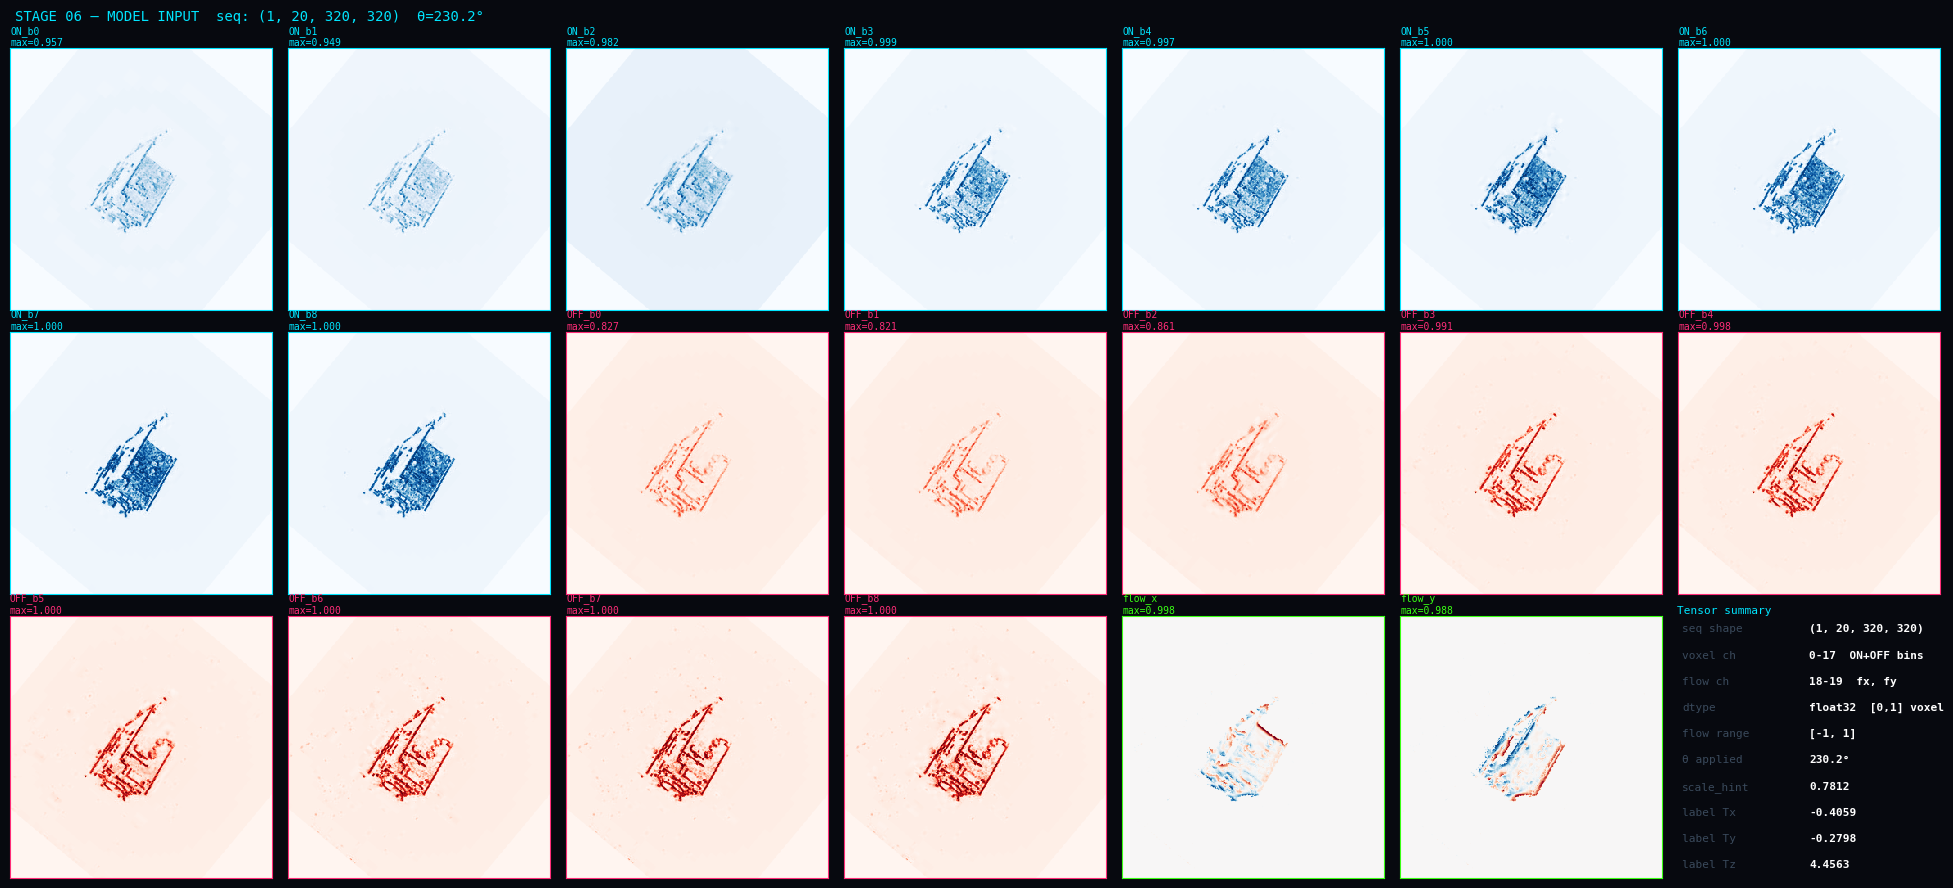

seq: (1, 20, 320, 320)  dtype=torch.float32  min=-0.9990  max=1.0000


In [12]:
# Assemble the full 20-channel tensor (18 voxel + 2 flow), with augmentation + rotation
random.seed(SEED); torch.manual_seed(SEED)
theta_final = random.uniform(0, 360)

# Apply augmentation pipeline
aug_r = img_r.clone()
if random.random() < 0.70: aug_r = step_blue_floor_vox(aug_r)
if random.random() < 0.65: aug_r = step_organic_noise_vox(aug_r)
if random.random() < 0.70: aug_r = step_vignette_vox(aug_r)
if random.random() < 0.40: aug_r = step_bg_suppression(aug_r)
aug_r = step_jpeg_vox(aug_r, quality=random.randint(60,78))

# Build 20-channel: voxel(18) + flow(2)
flow_tensor = torch.from_numpy(flow_r)  # (2, RES, RES)
tensor_20ch = torch.cat([aug_r, flow_tensor], dim=0)  # (20, RES, RES)

# Apply in-plane rotation to full 20-channel tensor
tensor_20ch_rot = step_in_plane_rotate(tensor_20ch, theta_final)

# Batch dimension → ready for model
seq = tensor_20ch_rot.unsqueeze(0)  # (1, 20, RES, RES)  [seq dim squeezed out]

fig, axes = plt.subplots(3, 7, figsize=(20, 9))
fig.patch.set_facecolor('#07090f')
fig.suptitle(f'STAGE 06 — MODEL INPUT  seq: (1, 20, {RES}, {RES})  θ={theta_final:.1f}°', 
             color=CYAN, fontsize=10, x=0.01, ha='left', fontfamily='monospace')

cmaps_on  = ['Blues']*T_BINS
cmaps_off = ['Reds']*T_BINS
cmaps_fl  = ['RdBu_r', 'RdBu_r']
all_cmaps = cmaps_on + cmaps_off + cmaps_fl
channel_names = [f'ON_b{b}' for b in range(T_BINS)] + [f'OFF_b{b}' for b in range(T_BINS)] + ['flow_x', 'flow_y']
channel_cols  = [CYAN]*T_BINS + [PINK]*T_BINS + [GREEN, GREEN]

for ch in range(20):
    row, col = ch // 7, ch % 7
    ax = axes[row][col]
    data = seq[0, ch].numpy()
    vmax = 1.0 if ch < 18 else max(abs(data.max()), abs(data.min()), 0.01)
    vmin = 0.0 if ch < 18 else -vmax
    ax.imshow(data, cmap=all_cmaps[ch], vmin=vmin, vmax=vmax, aspect='equal', interpolation='nearest')
    ax.set_title(f'{channel_names[ch]}\nmax={data.max():.3f}', 
                 color=channel_cols[ch], fontsize=7, pad=2, loc='left')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor(channel_cols[ch]); sp.set_linewidth(0.8)

# Last slot: summary
ax = axes[2][6]; ax.axis('off')
summary = [
    ('seq shape',    f'(1, 20, {RES}, {RES})'),
    ('voxel ch',     '0-17  ON+OFF bins'),
    ('flow ch',      '18-19  fx, fy'),
    ('dtype',        'float32  [0,1] voxel'),
    ('flow range',   '[-1, 1]'),
    ('θ applied',    f'{theta_final:.1f}°'),
    ('scale_hint',   f'{sc:.4f}'),
    ('label Tx',     f'{tx[FRAME_IDX]:.4f}'),
    ('label Ty',     f'{ty[FRAME_IDX]:.4f}'),
    ('label Tz',     f'{tz[FRAME_IDX]:.4f}'),
]
for i, (k, v) in enumerate(summary):
    ax.text(0.02, 0.97-i*0.10, k, transform=ax.transAxes, color=DIM, fontsize=8, va='top')
    ax.text(0.50, 0.97-i*0.10, v, transform=ax.transAxes, color='white', fontsize=8, va='top', fontweight='bold')
ax.set_title('Tensor summary', color=CYAN, fontsize=8, pad=2, loc='left')

plt.tight_layout()
plt.show()
print(f'seq: {tuple(seq.shape)}  dtype={seq.dtype}  min={seq.min():.4f}  max={seq.max():.4f}')

---
## Summary

| Stage | What happens | Output shape |
|-------|-------------|-------------|
| 0 | Load H5, read labels | — |
| 1 | Slice 400ms event window, count filter | ~100k events |
| 2 | Density centroid → crop box | (cx, cy, std_crop) |
| 3 | 18-channel voxel grid (img_f + img_r) | (18,320,320) × 2 |
| 4 | Optical flow: time-surface gradient | (2,320,320) |
| 5 | Augmentation suite (10 steps, probabilistic) | (18,320,320) |
| 5b | In-plane rotation θ~U(0°,360°) + pose label update | (18,320,320) |
| 6 | Concat voxel+flow → 20ch + rotate all channels | (1,20,320,320) |
| 7 | Batch 16 samples → GPU | (16,20,320,320) |